## Compute Median of StarterPacks

#### Purpose:

This script analyzes the influence level of accounts contained within Bluesky starter packs by computing follower statistics and examining how influence varies across detected communities.

#### Pipeline:
This step integrates three previously generated datasets:

**1. Starter Pack – Account pairs:** A dataset containing which accounts appear in each starter pack.

**2. Account profile information:** Collected using the Bluesky API, including follower counts and post counts for each account.

**3. Community detection results:** Output from the Leiden clustering step, which assigns each starter pack to one of the detected thematic communities.

#### Research Question: "Do different starter pack communiites promote accounts with differnt level of influence?"
By comparing median follower counts across communities, we can examine whether some thematic communities tend to contain more highly followed accounts while others consist primarily of smaller users. These results help us understand whether starter pack communities differ not only in topic but also in the influence structure of the accounts they promote.

In [44]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Load all Files:

In [2]:
accounts = pd.read_json("./data/Trang_accounts_all.jsonl", lines=True)
accounts_info = pd.read_json("./data/Trang_accounts_info.jsonl", lines=True)
community_label = pd.read_json("./data/Community_Detection.jsonl", lines=True)

In [40]:
community_label.head(5)

,SP URI,SP Description,cluster_id,community_id,label,confidence
0,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,education is the most powerful weapon which yo...,-1,3,Animal rescue activism (dogs and cats),0.98
1,at://did:plc:5i44ufyoaddlx2woq6jjooe2/app.bsky...,for memoir authors and readers to connect!,-1,11,"Writers, authors, and literary communities",0.91
2,at://did:plc:hyyr7fulewszq7evfnkvx2bd/app.bsky...,"nearly 100 mps, peers, ex-mps or ex-meps on bl...",-1,4,Mixed social communities and hobby groups,0.45
3,at://did:plc:7fiej65ln5nlyubac3ujduni/app.bsky...,"mps, councillors and others politicos in great...",-1,4,Mixed social communities and hobby groups,0.45
4,at://did:plc:4nlcdkzpa7nvbartn6hagkuc/app.bsky...,friendly wordle competition -vetted with artis...,-1,11,"Writers, authors, and literary communities",0.91


In [41]:
accounts.head(5)

,SP URI,SP DID,SP Creator DID,SP Creator Handle,SP Description,Account DID,Account Handler
0,at://did:plc:zdtz65xortdlxi7d6hlyz2j5/app.bsky...,bafyreie3wdnxditj3sbinyctdum23xk3x6luvdy6voy3o...,did:plc:zdtz65xortdlxi7d6hlyz2j5,motesandbeams.bsky.social,None,did:plc:tsksqpjisdvtusxq6ide5tzj,adamkinzinger.substack.com
1,at://did:plc:zdtz65xortdlxi7d6hlyz2j5/app.bsky...,bafyreie3wdnxditj3sbinyctdum23xk3x6luvdy6voy3o...,did:plc:zdtz65xortdlxi7d6hlyz2j5,motesandbeams.bsky.social,None,did:plc:nyxviptfyic2lvuorkr5yy3y,theatlantic.com
2,at://did:plc:zdtz65xortdlxi7d6hlyz2j5/app.bsky...,bafyreie3wdnxditj3sbinyctdum23xk3x6luvdy6voy3o...,did:plc:zdtz65xortdlxi7d6hlyz2j5,motesandbeams.bsky.social,None,did:plc:i3fhjvvkbmirhyu4aeihhrnv,wsj.com
3,at://did:plc:zdtz65xortdlxi7d6hlyz2j5/app.bsky...,bafyreie3wdnxditj3sbinyctdum23xk3x6luvdy6voy3o...,did:plc:zdtz65xortdlxi7d6hlyz2j5,motesandbeams.bsky.social,None,did:plc:ldlzqtvra3aylogmq4jqnvhm,inequalitymedia.bsky.social
4,at://did:plc:zdtz65xortdlxi7d6hlyz2j5/app.bsky...,bafyreie3wdnxditj3sbinyctdum23xk3x6luvdy6voy3o...,did:plc:zdtz65xortdlxi7d6hlyz2j5,motesandbeams.bsky.social,None,did:plc:npngl47gij5llus65j5fdujx,imcivicaction.bsky.social


##### Condense the analysis to starterpack with description:

In [5]:
# Only get the StarterPacks with description
sp_with_description = accounts[accounts["SP Description"].notna()]

In [6]:
# Merge the datasets. Starterpack|Accounts|with description starterpacks with accounts followers and posts information dataset
data = sp_with_description.merge(accounts_info, on="Account DID", how="left")

In [42]:
data.head(5)

,SP URI,SP DID,SP Creator DID,SP Creator Handle,SP Description,Account DID,Account Handler,Account Followers Count,Account Posts Count
0,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,bafyreidb7dfysn45jtudxaro6n6alqiemb5irmv2ztoan...,did:plc:oextljnuf4ix335o7aapym55,dwmfeed.bsky.social,Education is the most powerful weapon which yo...,did:plc:sorhbyjas5rgtuanglvmbyo2,martinstabe.ft.com,14700.0,74.0
1,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,bafyreidb7dfysn45jtudxaro6n6alqiemb5irmv2ztoan...,did:plc:oextljnuf4ix335o7aapym55,dwmfeed.bsky.social,Education is the most powerful weapon which yo...,did:plc:ul3dm3b76hu2cqla3qxb4v6u,data.ft.com,161048.0,901.0
2,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,bafyreidb7dfysn45jtudxaro6n6alqiemb5irmv2ztoan...,did:plc:oextljnuf4ix335o7aapym55,dwmfeed.bsky.social,Education is the most powerful weapon which yo...,did:plc:m5mauk2a3xu2j5nbjbzifm4z,foreignpolicy.com,57693.0,3753.0
3,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,bafyreidb7dfysn45jtudxaro6n6alqiemb5irmv2ztoan...,did:plc:oextljnuf4ix335o7aapym55,dwmfeed.bsky.social,Education is the most powerful weapon which yo...,did:plc:yb2l53aiavc2wh62akaxyb2z,mazzucatom.bsky.social,17239.0,659.0
4,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,bafyreidb7dfysn45jtudxaro6n6alqiemb5irmv2ztoan...,did:plc:oextljnuf4ix335o7aapym55,dwmfeed.bsky.social,Education is the most powerful weapon which yo...,did:plc:t2dfq4ktezmwjdnjjaygw4bl,newyorker.com,364739.0,6951.0


##### Compute the Median by StarterPacks:
Computes the median follower count for each starter pack by grouping all accounts within the same starter pack and calculating the median of their follower counts. The result is then sorted and merged with the starter pack creator information, allowing us to analyze and compare the influence levels of different starter packs.

In [8]:
median_followers = (
    data.groupby("SP URI")["Account Followers Count"]
    .median()
    .reset_index()
    .rename(columns={"Account Followers Count": "Median Followers"})
    .sort_values("Median Followers", ascending=False)
)
median_followers = median_followers.merge(
    data[['SP URI', 'SP Creator Handle']].drop_duplicates(),
    on='SP URI',
    how='left'
)

In [9]:
median_followers

,SP URI,Median Followers,SP Creator Handle
0,at://did:plc:gtpybk6vaeovmqxubj3ou4on/app.bsky...,1343452.0,ottawajames.bsky.social
1,at://did:plc:qupritxkgvi3keugivw34js7/app.bsky...,1323274.5,spincitysj95121.bsky.social
2,at://did:plc:jngy2joerne6leloyekghh2y/app.bsky...,1315450.0,nayandubey.bsky.social
3,at://did:plc:yxb2x2navrirwjcdnffiwmm3/app.bsky...,1298331.0,jwrhb.bsky.social
4,at://did:plc:u44npqsduxwfsam6l2exqrgg/app.bsky...,1298331.0,realranchbabe.bsky.social
...,...,...,...
20520,at://did:plc:cln7etscfbn37waplraojv2l/app.bsky...,3.0,boodoo.co
20521,at://did:plc:sktmtq522vt6bbmykmrojuzi/app.bsky...,2.5,chilkawasakuna.bsky.social
20522,at://did:plc:dumdscnz7vlpjtdmhsfpwxs4/app.bsky...,2.0,hopplite.bsky.social
20523,at://did:plc:nwerflyksrmbwg5xbejxwvsk/app.bsky...,2.0,huenix.com


##### Distribution of Median Followers per Starter Pakc:
This histogram shows the distribution of median follower counts across starter packs, indicating how typical account influence varies between packs. The logarithmic y-axis highlights that most starter packs contain accounts with relatively small follower bases, while only a small number of packs include accounts with much larger audiences.

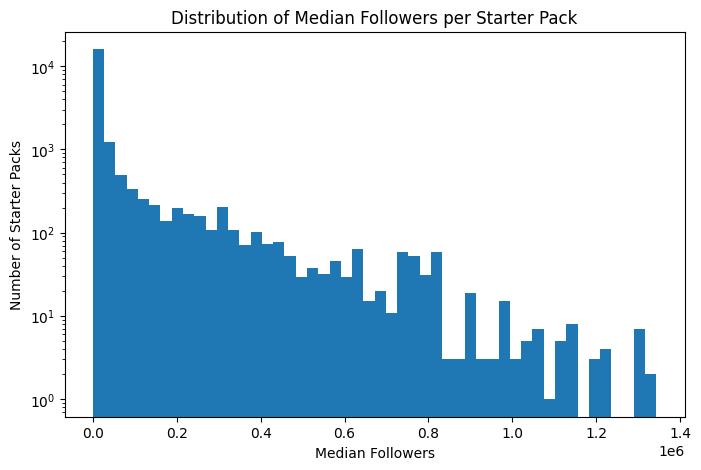

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(median_followers["Median Followers"], bins=50)
#plt.xscale("log")
plt.yscale("log")

plt.xlabel("Median Followers")
plt.ylabel("Number of Starter Packs")
plt.title("Distribution of Median Followers per Starter Pack")

plt.show()

#### Cumulative Distribution of Median Followers:
This cumulative distribution function (CDF) illustrates the proportion of starter packs whose median follower count falls below a given value. The logarithmic x-axis helps reveal how influence is distributed across packs, showing that a large fraction of starter packs contain accounts with relatively modest follower counts, while fewer packs reach higher influence levels.

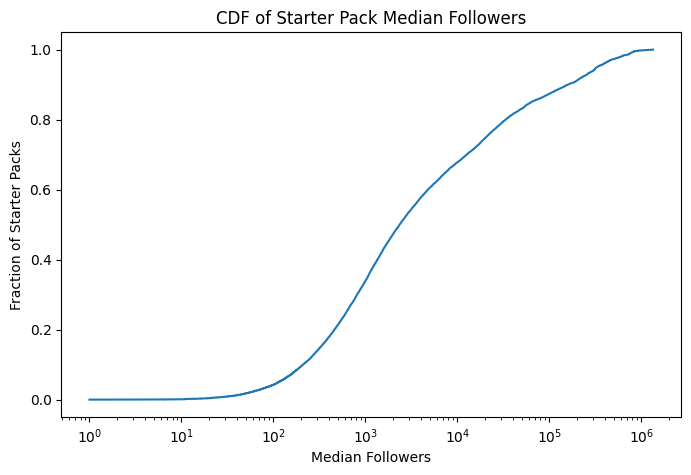

In [11]:
import numpy as np

x = np.sort(median_followers["Median Followers"])
y = np.arange(len(x)) / len(x)

plt.figure(figsize=(8,5))

plt.plot(x, y)

plt.xscale("log")

plt.xlabel("Median Followers")
plt.ylabel("Fraction of Starter Packs")
plt.title("CDF of Starter Pack Median Followers")

plt.show()


### Combine the Median and Communities Label

In [12]:
community_median = community_label.merge(median_followers, on="SP URI", how="left")

In [43]:
community_median.head(5)

,SP URI,SP Description,cluster_id,community_id,label,confidence,Median Followers,SP Creator Handle
0,at://did:plc:oextljnuf4ix335o7aapym55/app.bsky...,education is the most powerful weapon which yo...,-1,3,Animal rescue activism (dogs and cats),0.98,33690.0,dwmfeed.bsky.social
1,at://did:plc:5i44ufyoaddlx2woq6jjooe2/app.bsky...,for memoir authors and readers to connect!,-1,11,"Writers, authors, and literary communities",0.91,899.5,vallypee.bsky.social
2,at://did:plc:hyyr7fulewszq7evfnkvx2bd/app.bsky...,"nearly 100 mps, peers, ex-mps or ex-meps on bl...",-1,4,Mixed social communities and hobby groups,0.45,3076.5,richardbarfield.bsky.social
3,at://did:plc:7fiej65ln5nlyubac3ujduni/app.bsky...,"mps, councillors and others politicos in great...",-1,4,Mixed social communities and hobby groups,0.45,326.5,josephtiman.bsky.social
4,at://did:plc:4nlcdkzpa7nvbartn6hagkuc/app.bsky...,friendly wordle competition -vetted with artis...,-1,11,"Writers, authors, and literary communities",0.91,457.0,annenews.bsky.social


## Median Followers by Community:
Calculates the median follower count for each detected community by grouping starter packs according to their Leiden community labels. The communities are then sorted by their median follower values to compare the relative influence levels across different thematic communities.

In [14]:
community_stats = (
    community_median.groupby("community_id")["Median Followers"]
    .median()
    .reset_index()
)

community_stats = community_stats.sort_values("Median Followers", ascending=False)

In [27]:
community_labels = {
0: "General personal recommendations / favorite people",
1: "Artists and creative creators (visual art, comics)",
2: "Academic experts and research communities",
3: "Animal rescue activism (dogs and cats)",
4: "Mixed social communities and hobby groups",
5: "Personal identity and lifestyle accounts",
6: "Gaming, streaming, and tech creator communities",
7: "Noise or test descriptions",
8: "Non-English European-language communities",
9: "Journalists, media, and political commentary",
10: "Sports and gaming niche communities",
11: "Writers, authors, and literary communities",
12: "Portuguese and Spanish speaking communities",
13: "General Bluesky starter packs and discovery lists",
14: "Multilingual Asian and Middle Eastern communities",
15: "Music fandom communities",
16: "Feed curation and follow recommendation lists",
17: "Personal campaigns and niche activism lists",
18: "Spam or promotional service accounts"
}

##### Top 10 Communities by Median Follower Count:
This visualization highlights the top 10 communities with the highest median follower counts, allowing us to compare influence levels across different communities. By ranking communities based on the median follower counts of the starter packs they contain, the chart reveals which communities tend to promote more highly followed accounts.

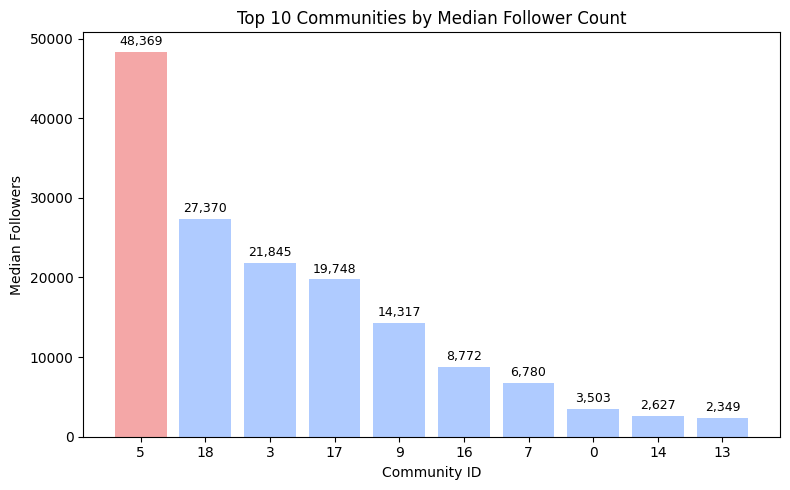

In [37]:
import matplotlib.pyplot as plt

community_stats = (
    community_median.groupby("community_id")["Median Followers"]
    .median()
    .reset_index()
)

top5_stats = (
    community_stats
    .sort_values("Median Followers", ascending=False)
    .head(10)
)

colors = ["#F4A7A7"] + ["#AFCBFF"] * 9

plt.figure(figsize=(8, 5))

plt.bar(
    top5_stats["community_id"].astype(str),
    top5_stats["Median Followers"],
    color=colors
)

plt.xlabel("Community ID")
plt.ylabel("Median Followers")
plt.title("Top 10 Communities by Median Follower Count")

for i, v in enumerate(top5_stats["Median Followers"]):
    plt.text(i, v + 500, f"{int(v):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Followers Distribution by Community

This figure shows the distribution of median follower counts across communities identified using the Leiden clustering algorithm. Communities are ordered by their median follower count, and the x-axis is displayed on a logarithmic scale to account for the heavy-tailed distribution of followers on the platform. The highlighted community represents the group with the highest median follower count, illustrating differences in audience size across communities.

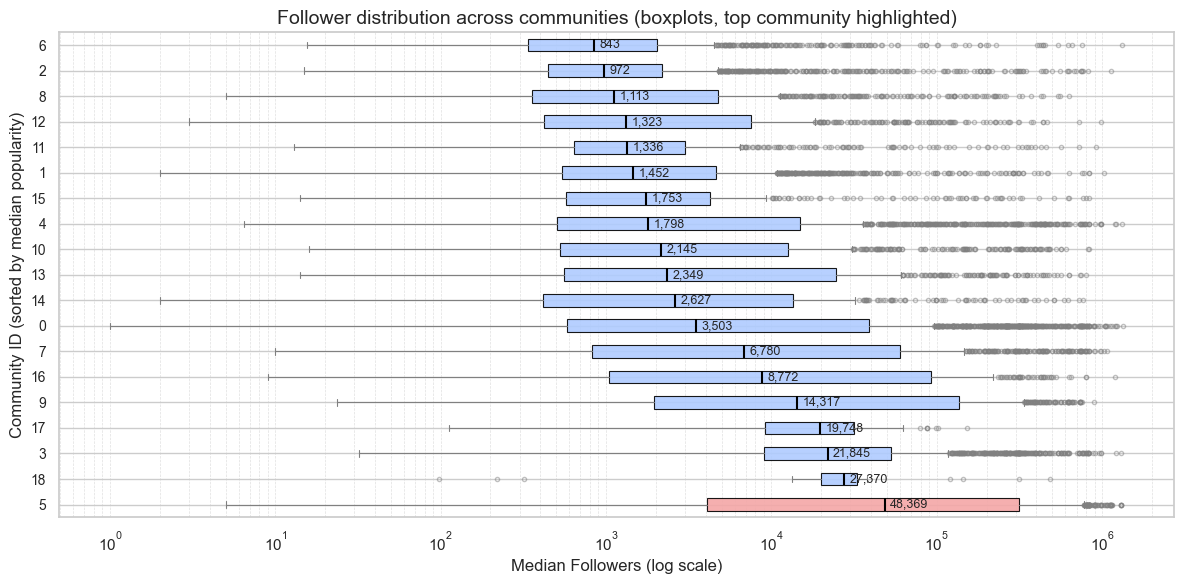

In [ ]:
# Improved boxplot for follower distributions across communities
sns.set(style="whitegrid")   # cleaner style

# --- INPUT: replace these names if your DataFrame uses different column names ---
# community_median: one row per starter-pack (or account aggregation) with columns:
#   - "community_id" (int)
#   - "Median Followers" (numeric, the per-pack median follower count)
df = community_median.copy()
# ------------------------------------------------------------------------------

# Compute per-community lists and medians
grouped = df.groupby("community_id")["Median Followers"]
median_by_comm = grouped.median().sort_values(ascending=False)   # descending by median
ordered_communities = median_by_comm.index.tolist()

# Prepare data for plotting: list of arrays in the sorted order
data_for_plot = [df.loc[df["community_id"] == cid, "Median Followers"].values
                 for cid in ordered_communities]

# Colors: highlight the top community, mute the rest
highlight_color = "#F4A7A7"    # pastel coral for top
other_color = "#AFCBFF"        # soft blue for others
colors = [highlight_color] + [other_color] * (len(ordered_communities) - 1)

# Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal boxplot (easier to read long labels / ids)
box = ax.boxplot(
    data_for_plot,
    vert=False,
    patch_artist=True,
    showfliers=True,
    whis=1.5,   # typical choice; change to 2.0 if you want more inclusive whiskers
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=0.8),
    whiskerprops=dict(color="gray", linewidth=0.8),
    capprops=dict(color="gray", linewidth=0.8),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="gray",
                    markersize=3, alpha=0.5)
)

# Color the boxes
for patch, c in zip(box["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)
    patch.set_edgecolor("black")

# Y ticks: show community ids (in the new order)
yticks = np.arange(1, len(ordered_communities) + 1)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(x)) for x in ordered_communities], fontsize=10)

# Log-scale for x (follower counts are heavy-tailed)
ax.set_xscale("log")

# Labels / title
ax.set_xlabel("Median Followers (log scale)", fontsize=12)
ax.set_ylabel("Community ID (sorted by median popularity)", fontsize=12)
ax.set_title("Follower distribution across communities (boxplots, top community highlighted)", fontsize=14)

# Annotate medians (numbers) to the right of each box
medians = median_by_comm.values
for i, med in enumerate(medians):
    ax.text(med * 1.08, i + 1, f"{int(med):,}", va="center", fontsize=9)  # multiply for offset

# grid for easier reading
ax.xaxis.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
# Save if you want:
# plt.savefig("improved_community_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Top Communities by Label:
This figure shows the most common topics among starter packs after community labeling. Personal recommendation–based starter packs appear most frequently, suggesting that users often curate lists around personal networks or favorite accounts rather than strictly topic-based communities.

In [17]:
label_counts = community_median["label"].value_counts().head(10)

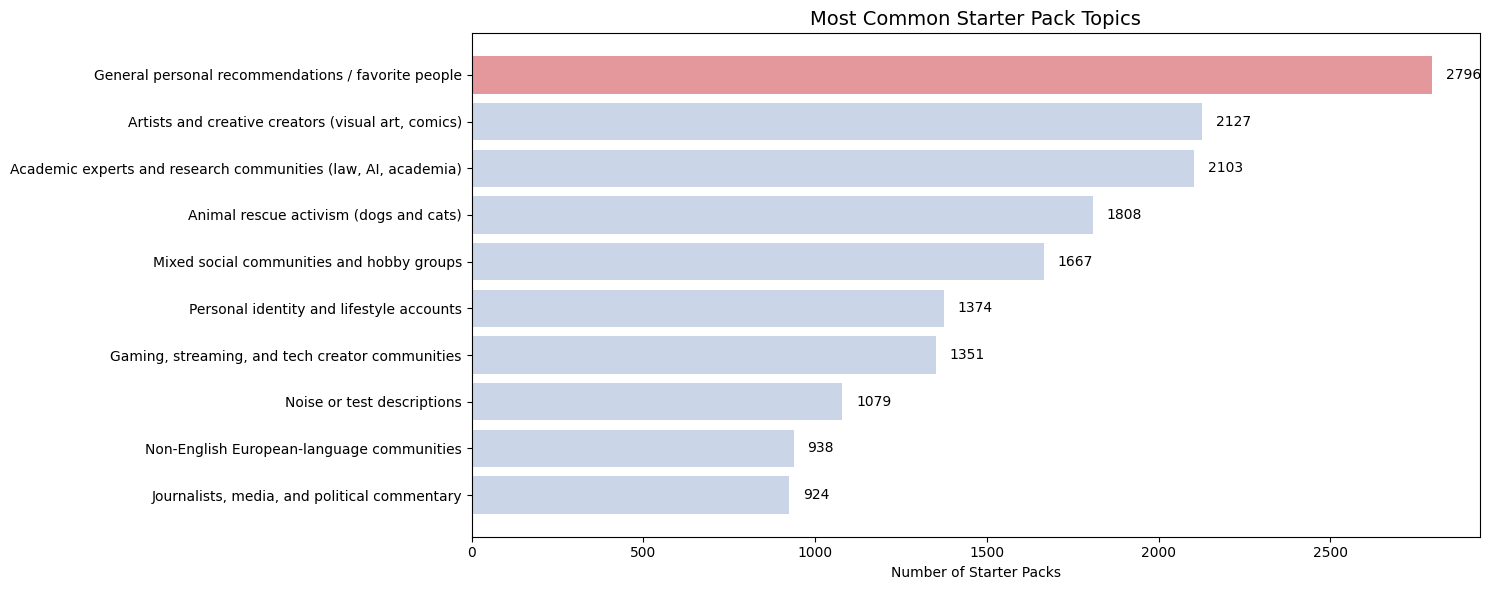

In [ ]:
# sort so largest is on top
label_counts = label_counts.sort_values()

# colors: highlight the largest one
colors = [
    "#E5989B" if "General personal" in label else "#CBD5E8"
    for label in label_counts.index
]

plt.figure(figsize=(15,6))

plt.barh(label_counts.index, label_counts.values, color=colors)

plt.title("Most Common Starter Pack Topics", fontsize=14)
plt.xlabel("Number of Starter Packs")

# annotate values
for i, v in enumerate(label_counts.values):
    plt.text(v + 40, i, str(v), va='center')

plt.tight_layout()
plt.show()